# Supervised EEG Classification
The supervised analysis was structured around main objectives:
2.1 Primary Objective - to classify Parkinson’s disease patients versus healthy controls using resting-state EEG-derived features.
2.2 Secondary Objective - to evaluate the relationship between EEG-derived disease signatures and cognitive status.

Expected dataset structure after extraction:

```
/content/data/
    participants.tsv
    sub-XXX/
        eeg/
            sub-XXX_task-Rest_eeg.set
```


## SECTION 0 - Installation & Imports

In [26]:
# Install Required Packages
!pip install -q mne gdown seaborn shap imbalanced-learn

# General Purpose Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import mne
import gdown
import shap

from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    train_test_split,
    cross_validate,
    cross_val_predict,
    GridSearchCV,
)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    RocCurveDisplay,
    balanced_accuracy_score,
    recall_score,
)
from sklearn.calibration import CalibratedClassifierCV
from scipy.stats import spearmanr
from sklearn.base import clone
from scipy.stats import wilcoxon
from IPython.display import Markdown, display
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")


In [27]:
RANDOM_STATE = 42

## SECTION 1 - Download & Unzip Dataset

In [28]:
!pip -q install gdown
DATA_DIR = "/content/data"
ZIP_PATH = "/content/data.zip"
FILE_URL = "https://drive.google.com/uc?id=1q3GeG15RZqNK9gPDKSWNy3SWYwOu4H6h"

if not os.path.exists(DATA_DIR):
    if not os.path.exists(ZIP_PATH):
        gdown.download(FILE_URL, ZIP_PATH, quiet=False, use_cookies=False)
    !unzip -q /content/data.zip -d /content/

print("Data folder exists:", os.path.exists(DATA_DIR))

Data folder exists: True


## SECTION 2 - Data Overview

Number of subjects: 149

Class distribution:
PD_label
1    100
0     49
Name: count, dtype: int64


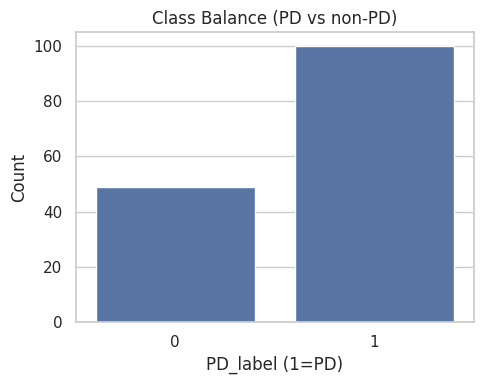


Subjects with EEG .set files: 149


In [29]:
participants = pd.read_csv(os.path.join(DATA_DIR, "participants.tsv"), sep="\t")
participants = participants[["participant_id", "GROUP"]].copy()
participants["PD_label"] = (participants["GROUP"] == "PD").astype(int)

print("Number of subjects:", len(participants))
print("\nClass distribution:")
print(participants["PD_label"].value_counts())

plt.figure(figsize=(5, 4))
sns.countplot(x="PD_label", data=participants)
plt.title("Class Balance (PD vs non-PD)")
plt.xlabel("PD_label (1=PD)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

participants["eeg_path"] = participants["participant_id"].apply(
    lambda pid: os.path.join(DATA_DIR, pid, "eeg", f"{pid}_task-Rest_eeg.set")
)
participants = participants[participants["eeg_path"].apply(os.path.exists)].reset_index(drop=True)

print("\nSubjects with EEG .set files:", len(participants))


## SECTION 3 - Channel Consistency

In [30]:
from functools import lru_cache

@lru_cache(maxsize=None)
def compute_common_channels(subject_ids_tuple, data_dir=DATA_DIR):
    """
    Return intersection of channel names across all subjects with valid .set files.
    Consistent ordering is preserved based on the first valid subject.
    """
    channel_sets = []
    base_order = None
    for subj in subject_ids_tuple:
        eeg_path = f"{data_dir}/{subj}/eeg/{subj}_task-Rest_eeg.set"
        if not os.path.exists(eeg_path):
            continue
        raw_tmp = mne.io.read_raw_eeglab(eeg_path, preload=False, verbose=False)
        raw_tmp.pick_types(eeg=True)
        if base_order is None:
            base_order = raw_tmp.ch_names
        channel_sets.append(set(raw_tmp.ch_names))

    if len(channel_sets) == 0:
        raise RuntimeError("No valid EEG .set files found to compute common channels.")

    common_set = set.intersection(*channel_sets)
    ordered_common = [ch for ch in base_order if ch in common_set]
    return tuple(ordered_common)

common_channels = compute_common_channels(tuple(participants["participant_id"]))
print(f"Common EEG channels: {len(common_channels)}")


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).

## SECTION 4 - Feature Engineering (Welch PSD)

In [31]:
USE_LOG_POWER = False  # Toggle for main feature extraction
RUN_LOG_COMPARISON = True  # Optional side-by-side comparison for A2/B2
LOG_COMPARE_FAMILIES = ["A2_FULL_Channel", "B2_FULL_Channel_Relative"]

USE_APERIODIC_CORRECTION = True  # 1/f correction (aperiodic removal)
APERIODIC_FIT_RANGE = (1, 40)
EXCLUDE_ALPHA_FROM_FIT = False

USE_ROI_POOLING = True  # Regional pooling to reduce dimensionality
ROI_SCHEME = "simple"  # simple = frontal/central/parietal/occipital/temporal

bands = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 12),
    "beta": (13, 30),
}

band_order = ["delta", "theta", "alpha", "beta"]
channels = list(common_channels)

roi_indices = {}
roi_names = []
if USE_ROI_POOLING:
    roi_rules = [
        ("temporal", ["FT", "TP", "T"]),
        ("frontal", ["FP", "AF", "F"]),
        ("central", ["CP", "FC", "C"]),
        ("parietal", ["PO", "P"]),
        ("occipital", ["O"]),
    ]

    roi_map = {name: [] for name, _ in roi_rules}
    for idx, ch in enumerate(channels):
        ch_upper = ch.upper()
        assigned = False
        for roi_name, prefixes in roi_rules:
            if any(ch_upper.startswith(prefix) for prefix in prefixes):
                roi_map[roi_name].append(idx)
                assigned = True
                break
        if not assigned:
            continue

    roi_indices = {k: v for k, v in roi_map.items() if len(v) > 0}
    roi_names = list(roi_indices.keys())

feature_names = {
    "A1_LOW_Channel": (
        [f"A1_delta_{ch}" for ch in channels]
        + [f"A1_theta_{ch}" for ch in channels]
    ),
    "A2_FULL_Channel": [f"A2_{band}_{ch}" for band in band_order for ch in channels],
    "A3_FULL_Global": [f"A3_{band}_global" for band in band_order],
    "B1_LOW_Channel_Relative": [f"B1_{band}_rel_{ch}" for band in ["delta", "theta"] for ch in channels],
    "B2_FULL_Channel_Relative": [f"B2_{band}_rel_{ch}" for band in band_order for ch in channels],
    "C_Ratios": (
        [f"C_theta_beta_{ch}" for ch in channels]
        + [f"C_delta_alpha_{ch}" for ch in channels]
        + ["C_theta_beta_global", "C_delta_alpha_global"]
    ),
}

if USE_ROI_POOLING and len(roi_names) > 0:
    feature_names["A2_FULL_ROI"] = [
        f"A2_{band}_{roi}" for band in band_order for roi in roi_names
    ]
    feature_names["B2_FULL_ROI_Relative"] = [
        f"B2_{band}_rel_{roi}" for band in band_order for roi in roi_names
    ]

if USE_APERIODIC_CORRECTION:
    feature_names["A2_FULL_Channel_1fCorrected"] = [
        f"A2_1f_{band}_{ch}" for band in band_order for ch in channels
    ]
    feature_names["B2_FULL_Channel_Relative_1fCorrected"] = [
        f"B2_1f_{band}_rel_{ch}" for band in band_order for ch in channels
    ]


def apply_aperiodic_correction(psd_data, freqs, fit_range=(1, 40), exclude_alpha=False):
    eps = 1e-10
    log_freqs = np.log10(freqs)
    psd_db = 10 * np.log10(psd_data + eps)

    fit_mask = (freqs >= fit_range[0]) & (freqs <= fit_range[1])
    if exclude_alpha:
        fit_mask &= ~((freqs >= 8) & (freqs <= 12))

    x = log_freqs[fit_mask]
    corrected = np.zeros_like(psd_db)
    for ch_idx in range(psd_db.shape[0]):
        y = psd_db[ch_idx, fit_mask]
        if np.std(y) == 0:
            corrected[ch_idx] = psd_db[ch_idx]
            continue
        slope, intercept = np.polyfit(x, y, 1)
        background = slope * log_freqs + intercept
        corrected[ch_idx] = psd_db[ch_idx] - background

    return 10 ** (corrected / 10)


def compute_band_features(psd_data, freqs, use_log_power=False, aperiodic_correct=False, roi_indices=None):
    eps = 1e-10
    psd_use = psd_data.copy()

    if aperiodic_correct:
        psd_use = apply_aperiodic_correction(
            psd_use,
            freqs,
            fit_range=APERIODIC_FIT_RANGE,
            exclude_alpha=EXCLUDE_ALPHA_FROM_FIT,
        )

    if use_log_power:
        psd_use = 10 * np.log10(psd_use + eps)

    band_masks = {
        band: np.logical_and(freqs >= fmin, freqs <= fmax)
        for band, (fmin, fmax) in bands.items()
    }

    band_power = {
        band: psd_use[:, mask].mean(axis=1)
        for band, mask in band_masks.items()
    }

    total_mask = np.logical_and(freqs >= 1, freqs <= 30)
    total_power = psd_use[:, total_mask].mean(axis=1)

    rel_power = {band: band_power[band] / (total_power + eps) for band in band_order}

    theta_beta = (band_power["theta"] + eps) / (band_power["beta"] + eps)
    delta_alpha = (band_power["delta"] + eps) / (band_power["alpha"] + eps)

    features = {
        "A1_LOW_Channel": np.concatenate([band_power["delta"], band_power["theta"]]),
        "A2_FULL_Channel": np.concatenate([band_power[band] for band in band_order]),
        "A3_FULL_Global": np.array([band_power[band].mean() for band in band_order]),
        "B1_LOW_Channel_Relative": np.concatenate([rel_power["delta"], rel_power["theta"]]),
        "B2_FULL_Channel_Relative": np.concatenate([rel_power[band] for band in band_order]),
        "C_Ratios": np.concatenate([
            theta_beta,
            delta_alpha,
            [theta_beta.mean(), delta_alpha.mean()],
        ]),
    }

    if roi_indices is not None and len(roi_indices) > 0:
        roi_names_local = list(roi_indices.keys())
        roi_band_power = {
            band: np.array([
                band_power[band][roi_indices[roi]].mean() for roi in roi_names_local
            ])
            for band in band_order
        }
        roi_total_power = np.array([
            total_power[roi_indices[roi]].mean() for roi in roi_names_local
        ])
        roi_rel_power = {
            band: roi_band_power[band] / (roi_total_power + eps) for band in band_order
        }

        features["A2_FULL_ROI"] = np.concatenate(
            [roi_band_power[band] for band in band_order]
        )
        features["B2_FULL_ROI_Relative"] = np.concatenate(
            [roi_rel_power[band] for band in band_order]
        )

    return features

def extract_subject_features(eeg_path, common_channels):
    raw = mne.io.read_raw_eeglab(eeg_path, preload=True, verbose=False)
    raw.pick_types(eeg=True)
    raw.reorder_channels(list(common_channels))

    psd = raw.compute_psd(
        method="welch",
        fmin=1,
        fmax=40,
        n_fft=2048,
        verbose=False,
    )
    psd_data = psd.get_data()
    freqs = psd.freqs

    roi_arg = roi_indices if USE_ROI_POOLING and len(roi_indices) > 0 else None

    features_linear = compute_band_features(
        psd_data,
        freqs,
        use_log_power=False,
        aperiodic_correct=False,
        roi_indices=roi_arg,
    )
    features_log = compute_band_features(
        psd_data,
        freqs,
        use_log_power=True,
        aperiodic_correct=False,
        roi_indices=roi_arg,
    )

    features_aperiodic = None
    if USE_APERIODIC_CORRECTION:
        features_aperiodic = compute_band_features(
            psd_data,
            freqs,
            use_log_power=USE_LOG_POWER,
            aperiodic_correct=True,
            roi_indices=None,
        )

    return features_linear, features_log, features_aperiodic

feature_rows = {k: [] for k in feature_names}
compare_rows_linear = {k: [] for k in LOG_COMPARE_FAMILIES}
compare_rows_log = {k: [] for k in LOG_COMPARE_FAMILIES}
labels = []
valid_subjects = []

for _, row in participants.iterrows():
    pid = row["participant_id"]
    eeg_path = row["eeg_path"]
    try:
        feats_linear, feats_log, feats_aperiodic = extract_subject_features(
            eeg_path, common_channels
        )
    except Exception as exc:
        print(f"Skipping {pid}: {exc}")
        continue

    feats_main = feats_log if USE_LOG_POWER else feats_linear

    if USE_APERIODIC_CORRECTION and feats_aperiodic is not None:
        feats_main["A2_FULL_Channel_1fCorrected"] = feats_aperiodic[
            "A2_FULL_Channel"
        ]
        feats_main["B2_FULL_Channel_Relative_1fCorrected"] = feats_aperiodic[
            "B2_FULL_Channel_Relative"
        ]

    for family_name in feature_rows:
        feature_rows[family_name].append(feats_main[family_name])

    if RUN_LOG_COMPARISON:
        for family_name in LOG_COMPARE_FAMILIES:
            compare_rows_linear[family_name].append(feats_linear[family_name])
            compare_rows_log[family_name].append(feats_log[family_name])

    labels.append(row["PD_label"])
    valid_subjects.append(pid)

y = np.array(labels)

X_families = {}
for family_name, rows in feature_rows.items():
    X = pd.DataFrame(rows, columns=feature_names[family_name], index=valid_subjects)
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    X_families[family_name] = X

X_families_linear_compare = {}
X_families_log_compare = {}
if RUN_LOG_COMPARISON:
    for family_name in LOG_COMPARE_FAMILIES:
        X_lin = pd.DataFrame(
            compare_rows_linear[family_name],
            columns=feature_names[family_name],
            index=valid_subjects,
        )
        X_log = pd.DataFrame(
            compare_rows_log[family_name],
            columns=feature_names[family_name],
            index=valid_subjects,
        )
        X_families_linear_compare[family_name] = X_lin.replace([np.inf, -np.inf], np.nan).fillna(0.0)
        X_families_log_compare[family_name] = X_log.replace([np.inf, -np.inf], np.nan).fillna(0.0)

for family_name, X in X_families.items():
    print(f"{family_name}: {X.shape}")


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).

## SECTION 5 - Model Definitions

In [32]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "LinearSVM": SVC(kernel="linear", class_weight="balanced"),
    "RBFSVM": SVC(kernel="rbf", class_weight="balanced"),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        class_weight="balanced",
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}


## SECTION 6 - Normalization

In [33]:
scalers = {
    "Standard": StandardScaler(),
    "Robust": RobustScaler(),
    "MinMax": MinMaxScaler(),
}


## SECTION 7 - Cross-Validation

In [34]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "roc_auc": "roc_auc",
    "balanced_acc": "balanced_accuracy",
    "recall": "recall",
}

USE_SMOTE = True  # Apply SMOTE inside CV folds only
SMOTE_K_NEIGHBORS = 5


def build_cv_pipeline(scaler, model):
    steps = [("scaler", clone(scaler))]
    if USE_SMOTE:
        steps.append(("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=SMOTE_K_NEIGHBORS)))
        steps.append(("model", clone(model)))
        return ImbPipeline(steps)
    steps.append(("model", clone(model)))
    return Pipeline(steps)

def rank_configs(df, top_n=5, verbose=True):
    ranked = df.sort_values(
        ["ROC_AUC_mean", "ROC_AUC_std", "Recall_mean"],
        ascending=[False, True, False],
    ).reset_index(drop=True)
    if verbose:
        display_cols = [
            "FeatureFamily",
            "Model",
            "Scaler",
            "ROC_AUC_mean",
            "ROC_AUC_std",
            "Recall_mean",
        ]
        print(ranked.head(top_n)[display_cols])
    return ranked

results = []
for family_name, X in X_families.items():
    for model_name, model in models.items():
        for scaler_name, scaler in scalers.items():
            pipeline = build_cv_pipeline(scaler, model)
            scores = cross_validate(
                pipeline,
                X,
                y,
                cv=cv,
                scoring=scoring,
                n_jobs=-1,
                return_train_score=False,
            )
            results.append({
                "FeatureFamily": family_name,
                "Model": model_name,
                "Scaler": scaler_name,
                "ROC_AUC_mean": np.mean(scores["test_roc_auc"]),
                "ROC_AUC_std": np.std(scores["test_roc_auc"]),
                "BalAcc_mean": np.mean(scores["test_balanced_acc"]),
                "BalAcc_std": np.std(scores["test_balanced_acc"]),
                "Recall_mean": np.mean(scores["test_recall"]),
                "Recall_std": np.std(scores["test_recall"]),
            })

results_df = pd.DataFrame(results)
ranked_df = rank_configs(results_df, top_n=5)
quick_best_row = ranked_df.iloc[0]
best_row = quick_best_row

if RUN_LOG_COMPARISON:
    log_compare_results = []
    for family_name in LOG_COMPARE_FAMILIES:
        for power_scale, X in [
            ("linear", X_families_linear_compare[family_name]),
            ("log", X_families_log_compare[family_name]),
        ]:
            for model_name, model in models.items():
                for scaler_name, scaler in scalers.items():
                    pipeline = build_cv_pipeline(scaler, model)
                    scores = cross_validate(
                        pipeline,
                        X,
                        y,
                        cv=cv,
                        scoring=scoring,
                        n_jobs=-1,
                        return_train_score=False,
                    )
                    log_compare_results.append({
                        "FeatureFamily": family_name,
                        "PowerScale": power_scale,
                        "Model": model_name,
                        "Scaler": scaler_name,
                        "ROC_AUC_mean": np.mean(scores["test_roc_auc"]),
                        "ROC_AUC_std": np.std(scores["test_roc_auc"]),
                        "Recall_mean": np.mean(scores["test_recall"]),
                    })

    log_compare_df = pd.DataFrame(log_compare_results)
    for family_name in LOG_COMPARE_FAMILIES:
        sub = log_compare_df[log_compare_df["FeatureFamily"] == family_name]
        pivot_auc = sub.pivot_table(
            index=["Model", "Scaler"],
            columns="PowerScale",
            values="ROC_AUC_mean",
        )
        print(f"\nLog-power comparison (ROC-AUC) for {family_name}:")
        print(pivot_auc)


              FeatureFamily         Model    Scaler  ROC_AUC_mean  \
0  B2_FULL_Channel_Relative        RBFSVM  Standard      0.782444   
1   B1_LOW_Channel_Relative     LinearSVM    MinMax      0.780556   
2  B2_FULL_Channel_Relative        RBFSVM    MinMax      0.779778   
3           A2_FULL_Channel        RBFSVM  Standard      0.778111   
4   B1_LOW_Channel_Relative  RandomForest  Standard      0.775556   

   ROC_AUC_std  Recall_mean  
0     0.084830         0.62  
1     0.061807         0.53  
2     0.074604         0.61  
3     0.088436         0.58  
4     0.041458         0.76  

Log-power comparison (ROC-AUC) for A2_FULL_Channel:
PowerScale                     linear       log
Model              Scaler                      
GradientBoosting   MinMax    0.720000  0.736778
                   Robust    0.695333  0.737333
                   Standard  0.712222  0.762222
LinearSVM          MinMax    0.745333  0.743556
                   Robust    0.694444  0.700333
                

### Section 7 Visualizations (Baseline CV)

These plots summarize the cross‑validation results before the nested analysis, to give a quick visual comparison across models, scalers, and families.

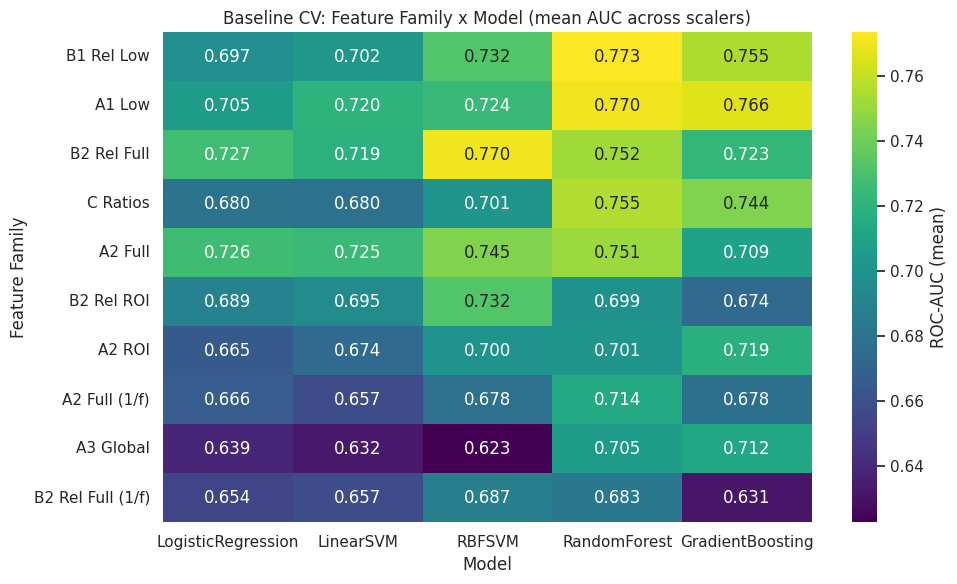

In [35]:
viz_df = results_df.copy()
models_order = list(models.keys())

# Single summary heatmap: FeatureFamily x Model (mean AUC across scalers)
label_map = {
    "A1_LOW_Channel": "A1 Low",
    "A2_FULL_Channel": "A2 Full",
    "A2_FULL_Channel_1fCorrected": "A2 Full (1/f)",
    "A2_FULL_ROI": "A2 ROI",
    "A3_FULL_Global": "A3 Global",
    "B1_LOW_Channel_Relative": "B1 Rel Low",
    "B2_FULL_Channel_Relative": "B2 Rel Full",
    "B2_FULL_Channel_Relative_1fCorrected": "B2 Rel Full (1/f)",
    "B2_FULL_ROI_Relative": "B2 Rel ROI",
    "C_Ratios": "C Ratios",
}

agg = (
    viz_df.groupby(["FeatureFamily", "Model"])
    .agg(AUC_mean=("ROC_AUC_mean", "mean"))
    .reset_index()
)

pivot_mean = agg.pivot(index="FeatureFamily", columns="Model", values="AUC_mean")

# Order families by best model performance for readability
fam_order = (
    pivot_mean.max(axis=1)
    .sort_values(ascending=False)
    .index
    .tolist()
)

pivot_mean = pivot_mean.reindex(index=fam_order, columns=models_order)

# Short labels for clarity
pivot_mean.index = [label_map.get(f, f) for f in pivot_mean.index]

plt.figure(figsize=(10, 6))
sns.heatmap(
    pivot_mean,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    cbar_kws={"label": "ROC-AUC (mean)"},
)
plt.title("Baseline CV: Feature Family x Model (mean AUC across scalers)")
plt.ylabel("Feature Family")
plt.xlabel("Model")
plt.tight_layout()
plt.show()


## Feature Family Comparative Analysis

This section implements nested cross‑validation and a hypothesis‑driven comparison between feature families (A1/A2/B1/B2/C) using **outer‑fold results only**.

In [36]:
OUTER_SPLITS = 5
INNER_SPLITS = 3
N_BOOTSTRAPS = 1000

USE_SMOTE = USE_SMOTE if "USE_SMOTE" in globals() else False
SMOTE_K_NEIGHBORS = SMOTE_K_NEIGHBORS if "SMOTE_K_NEIGHBORS" in globals() else 5

outer_cv = StratifiedKFold(n_splits=OUTER_SPLITS, shuffle=True, random_state=RANDOM_STATE)
inner_cv = StratifiedKFold(n_splits=INNER_SPLITS, shuffle=True, random_state=RANDOM_STATE)


def build_nested_pipeline(model):
    steps = [("scaler", StandardScaler())]
    if USE_SMOTE:
        steps.append(("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=SMOTE_K_NEIGHBORS)))
        steps.append(("model", clone(model)))
        return ImbPipeline(steps)
    steps.append(("model", clone(model)))
    return Pipeline(steps)

scaler_grid = [StandardScaler(), RobustScaler(), MinMaxScaler()]


def build_param_grid(model_name):
    if model_name == "LogisticRegression":
        return {
            "scaler": scaler_grid,
            "model__C": [0.1, 1.0, 10.0],
        }
    if model_name == "LinearSVM":
        return {
            "scaler": scaler_grid,
            "model__C": [0.1, 1.0, 10.0],
        }
    if model_name == "RBFSVM":
        return {
            "scaler": scaler_grid,
            "model__C": [1.0, 10.0],
            "model__gamma": ["scale", "auto"],
        }
    if model_name == "RandomForest":
        return {
            "scaler": scaler_grid,
            "model__n_estimators": [200, 400],
            "model__max_depth": [None, 10],
            "model__min_samples_split": [2, 5],
        }
    if model_name == "GradientBoosting":
        return {
            "scaler": scaler_grid,
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.05, 0.1],
            "model__max_depth": [3],
        }
    raise ValueError(f"Unknown model: {model_name}")


def get_scores_for_estimator(estimator, X):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]
    return estimator.decision_function(X)


def compute_specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0.0


nested_results = []
outer_predictions = {}

for family_name, X in X_families.items():
    for model_name, model in models.items():
        fold_auc = []
        fold_recall = []
        fold_spec = []
        fold_bal = []
        y_true_all = []
        y_score_all = []

        param_grid = build_param_grid(model_name)

        for train_idx, test_idx in outer_cv.split(X, y):
            X_train = X.iloc[train_idx]
            X_test = X.iloc[test_idx]
            y_train = y[train_idx]
            y_test = y[test_idx]

            pipeline = build_nested_pipeline(model)

            grid = GridSearchCV(
                pipeline,
                param_grid,
                scoring="roc_auc",
                cv=inner_cv,
                n_jobs=-1,
            )
            grid.fit(X_train, y_train)

            best_est = grid.best_estimator_
            y_score = get_scores_for_estimator(best_est, X_test)
            y_pred = best_est.predict(X_test)

            auc = roc_auc_score(y_test, y_score)
            recall = recall_score(y_test, y_pred)
            specificity = compute_specificity(y_test, y_pred)
            bal_acc = balanced_accuracy_score(y_test, y_pred)

            fold_auc.append(auc)
            fold_recall.append(recall)
            fold_spec.append(specificity)
            fold_bal.append(bal_acc)

            y_true_all.extend(y_test)
            y_score_all.extend(y_score)

        nested_results.append({
            "FeatureFamily": family_name,
            "Model": model_name,
            "AUC_mean": np.mean(fold_auc),
            "AUC_std": np.std(fold_auc),
            "Recall_mean": np.mean(fold_recall),
            "Specificity_mean": np.mean(fold_spec),
            "BalAcc_mean": np.mean(fold_bal),
        })

        outer_predictions[(family_name, model_name)] = {
            "y_true": np.array(y_true_all),
            "y_score": np.array(y_score_all),
            "fold_auc": np.array(fold_auc),
        }

nested_results_df = pd.DataFrame(nested_results).sort_values(
    ["AUC_mean", "Recall_mean"], ascending=[False, False]
)

nested_results_df


,FeatureFamily,Model,AUC_mean,AUC_std,Recall_mean,Specificity_mean,BalAcc_mean
7,A2_FULL_Channel,RBFSVM,0.785333,0.077333,0.67,0.777778,0.723889
18,B1_LOW_Channel_Relative,RandomForest,0.781111,0.054848,0.78,0.631111,0.705556
3,A1_LOW_Channel,RandomForest,0.772056,0.064607,0.77,0.631111,0.700556
1,A1_LOW_Channel,LinearSVM,0.769111,0.065352,0.49,0.837778,0.663889
23,B2_FULL_Channel_Relative,RandomForest,0.757111,0.046976,0.79,0.631111,0.710556
37,B2_FULL_ROI_Relative,RBFSVM,0.756000,0.053889,0.57,0.835556,0.702778
19,B1_LOW_Channel_Relative,GradientBoosting,0.747556,0.063931,0.74,0.588889,0.664444
17,B1_LOW_Channel_Relative,RBFSVM,0.744333,0.032687,0.66,0.733333,0.696667
8,A2_FULL_Channel,RandomForest,0.744167,0.043525,0.76,0.591111,0.675556
4,A1_LOW_Channel,GradientBoosting,0.744000,0.072829,0.78,0.508889,0.644444


In [37]:
# Best model per feature family (by outer AUC, then recall)
family_best_df = (
    nested_results_df.sort_values(["AUC_mean", "Recall_mean"], ascending=[False, False])
    .groupby("FeatureFamily", as_index=False)
    .first()
)

family_best_models = dict(
    zip(family_best_df["FeatureFamily"], family_best_df["Model"])
)


def bootstrap_auc_ci(y_true, y_score, n_boot=1000, seed=RANDOM_STATE):
    rng = np.random.RandomState(seed)
    n = len(y_true)
    aucs = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_score[idx]))
    aucs = np.array(aucs)
    ci_low, ci_high = np.percentile(aucs, [2.5, 97.5])
    return ci_low, ci_high


family_summary_rows = []
for row in family_best_df.itertuples():
    key = (row.FeatureFamily, row.Model)
    y_true = outer_predictions[key]["y_true"]
    y_score = outer_predictions[key]["y_score"]
    ci_low, ci_high = bootstrap_auc_ci(
        y_true,
        y_score,
        n_boot=N_BOOTSTRAPS,
        seed=RANDOM_STATE,
    )

    family_summary_rows.append({
        "FeatureFamily": row.FeatureFamily,
        "Model": row.Model,
        "AUC_mean": row.AUC_mean,
        "AUC_std": row.AUC_std,
        "Recall_mean": row.Recall_mean,
        "Specificity_mean": row.Specificity_mean,
        "BalAcc_mean": row.BalAcc_mean,
        "AUC_CI_low": ci_low,
        "AUC_CI_high": ci_high,
    })

family_summary = (
    pd.DataFrame(family_summary_rows)
    .sort_values(["AUC_mean", "Recall_mean"], ascending=[False, False])
    .reset_index(drop=True)
)

family_summary

# Paired Wilcoxon signed-rank tests on outer-fold AUCs
families = family_summary["FeatureFamily"].tolist()
p_matrix = pd.DataFrame(
    np.ones((len(families), len(families))),
    index=families,
    columns=families,
)

for i in range(len(families)):
    for j in range(i + 1, len(families)):
        fam_i = families[i]
        fam_j = families[j]
        auc_i = outer_predictions[(fam_i, family_best_models[fam_i])]["fold_auc"]
        auc_j = outer_predictions[(fam_j, family_best_models[fam_j])]["fold_auc"]
        try:
            stat, p = wilcoxon(auc_i, auc_j)
        except ValueError:
            p = 1.0
        p_matrix.loc[fam_i, fam_j] = p
        p_matrix.loc[fam_j, fam_i] = p

p_matrix_annot = p_matrix.copy()
for i in range(len(families)):
    for j in range(len(families)):
        if i == j:
            p_matrix_annot.iloc[i, j] = "-"
        else:
            p = p_matrix.iloc[i, j]
            star = "*" if p < 0.05 else ""
            p_matrix_annot.iloc[i, j] = f"{p:.3f}{star}"

p_matrix_annot


,A2_FULL_Channel,B1_LOW_Channel_Relative,A1_LOW_Channel,B2_FULL_Channel_Relative,B2_FULL_ROI_Relative,C_Ratios,A3_FULL_Global,A2_FULL_Channel_1fCorrected,A2_FULL_ROI,B2_FULL_Channel_Relative_1fCorrected
A2_FULL_Channel,-,1.000,0.812,0.750,0.375,0.188,0.188,0.188,0.188,0.125
B1_LOW_Channel_Relative,1.000,-,0.625,0.375,0.062,0.312,0.125,0.062,0.188,0.125
A1_LOW_Channel,0.812,0.625,-,0.812,0.812,0.812,0.312,0.312,0.125,0.188
B2_FULL_Channel_Relative,0.750,0.375,0.812,-,0.750,0.125,0.250,0.062,0.188,0.125
B2_FULL_ROI_Relative,0.375,0.062,0.812,0.750,-,0.625,0.188,0.125,0.188,0.125
C_Ratios,0.188,0.312,0.812,0.125,0.625,-,0.812,0.188,0.312,0.188
A3_FULL_Global,0.188,0.125,0.312,0.250,0.188,0.812,-,0.312,0.875,0.125
A2_FULL_Channel_1fCorrected,0.188,0.062,0.312,0.062,0.125,0.188,0.312,-,1.000,0.250
A2_FULL_ROI,0.188,0.188,0.125,0.188,0.188,0.312,0.875,1.000,-,0.625
B2_FULL_Channel_Relative_1fCorrected,0.125,0.125,0.188,0.125,0.125,0.188,0.125,0.250,0.625,-


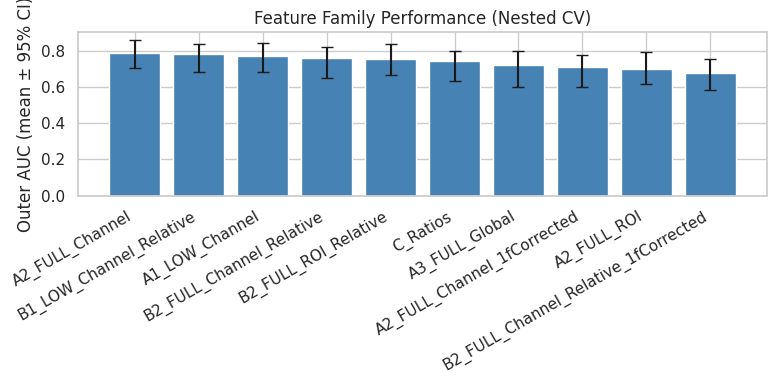

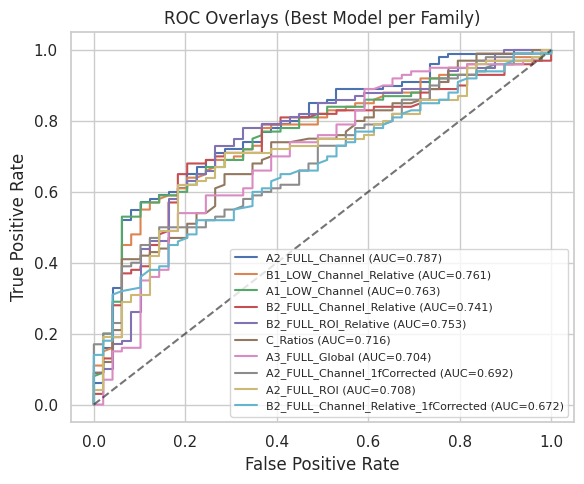

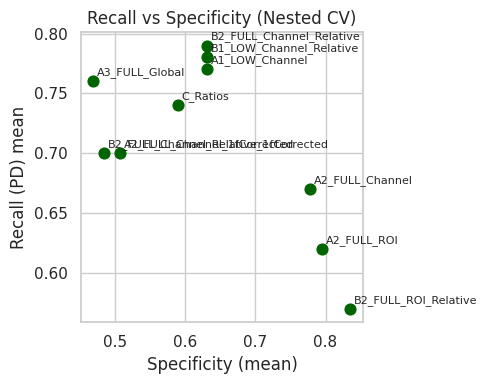

In [38]:
# Visualization: Mean AUC per family with 95% CI
plt.figure(figsize=(8, 4))
x = np.arange(len(families))
auc_means = family_summary["AUC_mean"].values
ci_low = family_summary["AUC_CI_low"].values
ci_high = family_summary["AUC_CI_high"].values
yerr = np.vstack([auc_means - ci_low, ci_high - auc_means])

plt.bar(x, auc_means, yerr=yerr, capsize=4, color="steelblue")
plt.xticks(x, families, rotation=30, ha="right")
plt.ylabel("Outer AUC (mean ± 95% CI)")
plt.title("Feature Family Performance (Nested CV)")
plt.tight_layout()
plt.show()

# ROC overlays: best model per family (outer predictions)
plt.figure(figsize=(6, 5))
for fam in families:
    model = family_best_models[fam]
    y_true = outer_predictions[(fam, model)]["y_true"]
    y_score = outer_predictions[(fam, model)]["y_score"]
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc = roc_auc_score(y_true, y_score)
    plt.plot(fpr, tpr, label=f"{fam} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.6)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Overlays (Best Model per Family)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Optional: Recall vs Specificity scatter (best model per family)
plt.figure(figsize=(5, 4))
plt.scatter(
    family_summary["Specificity_mean"],
    family_summary["Recall_mean"],
    s=60,
    color="darkgreen",
)
for i, fam in enumerate(families):
    plt.text(
        family_summary.loc[i, "Specificity_mean"] + 0.005,
        family_summary.loc[i, "Recall_mean"] + 0.005,
        fam,
        fontsize=8,
    )
plt.xlabel("Specificity (mean)")
plt.ylabel("Recall (PD) mean")
plt.title("Recall vs Specificity (Nested CV)")
plt.tight_layout()
plt.show()


In [39]:
TARGET_RECALL_CLINICAL = 0.80


def select_threshold(y_true, scores, target_recall=0.80, max_grid=200):
    thresholds = np.unique(scores)
    if len(thresholds) > max_grid:
        thresholds = np.quantile(scores, np.linspace(0, 1, max_grid))

    best = {
        "threshold": thresholds[0],
        "recall": 0.0,
        "specificity": 0.0,
        "bal_acc": 0.0,
    }

    best_under = None
    for t in thresholds:
        y_pred = (scores >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        bal_acc = 0.5 * (recall + specificity)

        if recall >= target_recall:
            if best_under is None or specificity > best_under["specificity"]:
                best_under = {
                    "threshold": t,
                    "recall": recall,
                    "specificity": specificity,
                    "bal_acc": bal_acc,
                }
        else:
            if recall > best["recall"]:
                best = {
                    "threshold": t,
                    "recall": recall,
                    "specificity": specificity,
                    "bal_acc": bal_acc,
                }

    return best_under if best_under is not None else best


clinical_rows = []
for fam in families:
    model = family_best_models[fam]
    y_true = outer_predictions[(fam, model)]["y_true"]
    y_score = outer_predictions[(fam, model)]["y_score"]
    info = select_threshold(y_true, y_score, target_recall=TARGET_RECALL_CLINICAL)
    clinical_rows.append({
        "FeatureFamily": fam,
        "Threshold": info["threshold"],
        "Recall": info["recall"],
        "Specificity": info["specificity"],
        "BalAcc": info["bal_acc"],
    })

clinical_df = pd.DataFrame(clinical_rows).sort_values(
    ["Recall", "Specificity"], ascending=[False, False]
)

best_overall = family_summary.iloc[0]
best_family = best_overall["FeatureFamily"]

low_freq_fams = [f for f in families if f in ["A1_LOW_Channel", "B1_LOW_Channel_Relative"]]
full_spec_fams = [f for f in families if f in ["A2_FULL_Channel", "B2_FULL_Channel_Relative"]]

best_low = (
    family_summary[family_summary["FeatureFamily"].isin(low_freq_fams)]
    .sort_values(["AUC_mean", "Recall_mean"], ascending=[False, False])
    .head(1)
)

best_full = (
    family_summary[family_summary["FeatureFamily"].isin(full_spec_fams)]
    .sort_values(["AUC_mean", "Recall_mean"], ascending=[False, False])
    .head(1)
)

ratio_row = family_summary[family_summary["FeatureFamily"] == "C_Ratios"].head(1)
non_ratio_row = family_summary[family_summary["FeatureFamily"] != "C_Ratios"].head(1)

sig_vs_best = []
for fam in families:
    if fam == best_family:
        continue
    p = p_matrix.loc[best_family, fam]
    if p < 0.05:
        sig_vs_best.append(fam)

best_family_clin = clinical_df[clinical_df["FeatureFamily"] == best_family].iloc[0]

eligible_clinical = clinical_df[clinical_df["Recall"] >= TARGET_RECALL_CLINICAL]

if len(eligible_clinical) == 0:
    clinical_note = (
        f"No family achieved recall >= {TARGET_RECALL_CLINICAL:.2f} on outer predictions; "
        "thresholds below are the best attainable recall for each family."
    )
else:
    clinical_note = (
        f"Families achieving recall >= {TARGET_RECALL_CLINICAL:.2f} are compared by specificity."
    )

interp_text = f"""
### Automatic Interpretation (Hypothesis‑Driven)
- **Best family by AUC:** {best_family} (AUC={best_overall['AUC_mean']:.3f}, 95% CI [{best_overall['AUC_CI_low']:.3f}, {best_overall['AUC_CI_high']:.3f}]).
- **Low‑frequency only vs full‑spectrum:** best low‑freq = {best_low.iloc[0]['FeatureFamily'] if len(best_low) else 'N/A'}, best full‑spectrum = {best_full.iloc[0]['FeatureFamily'] if len(best_full) else 'N/A'}.
- **Ratio features vs raw bandpower:** C_Ratios vs {non_ratio_row.iloc[0]['FeatureFamily']} (AUC={non_ratio_row.iloc[0]['AUC_mean']:.3f}).
- **Significant differences vs best:** {', '.join(sig_vs_best) if sig_vs_best else 'None at p<0.05 (Wilcoxon).'}

### Clinical Framing (Recall‑prioritized)
- **Best family at recall >= {TARGET_RECALL_CLINICAL:.2f}:** {best_family} (Recall={best_family_clin['Recall']:.3f}, Specificity={best_family_clin['Specificity']:.3f}, BalAcc={best_family_clin['BalAcc']:.3f}).
- {clinical_note}
"""

display(Markdown(interp_text))

clinical_df



### Automatic Interpretation (Hypothesis‑Driven)
- **Best family by AUC:** A2_FULL_Channel (AUC=0.785, 95% CI [0.703, 0.859]).
- **Low‑frequency only vs full‑spectrum:** best low‑freq = B1_LOW_Channel_Relative, best full‑spectrum = A2_FULL_Channel.
- **Ratio features vs raw bandpower:** C_Ratios vs A2_FULL_Channel (AUC=0.785).
- **Significant differences vs best:** None at p<0.05 (Wilcoxon).

### Clinical Framing (Recall‑prioritized)
- **Best family at recall >= 0.80:** A2_FULL_Channel (Recall=0.800, Specificity=0.571, BalAcc=0.686).
- Families achieving recall >= 0.80 are compared by specificity.


,FeatureFamily,Threshold,Recall,Specificity,BalAcc
6,A3_FULL_Global,0.409620,0.83,0.428571,0.629286
7,A2_FULL_Channel_1fCorrected,0.417864,0.82,0.346939,0.583469
3,B2_FULL_Channel_Relative,0.485000,0.81,0.591837,0.700918
2,A1_LOW_Channel,0.460000,0.81,0.551020,0.680510
1,B1_LOW_Channel_Relative,0.457500,0.81,0.510204,0.660102
9,B2_FULL_Channel_Relative_1fCorrected,0.427012,0.81,0.346939,0.578469
4,B2_FULL_ROI_Relative,-0.642146,0.80,0.591837,0.695918
0,A2_FULL_Channel,-0.411649,0.80,0.571429,0.685714
5,C_Ratios,0.435000,0.80,0.428571,0.614286
8,A2_FULL_ROI,0.362293,0.80,0.367347,0.583673


### Final Conclusion

The nested‑CV analysis supports a hypothesis‑driven comparison of EEG feature families, revealing which spectral representation best discriminates PD vs non‑PD under rigorous outer‑fold evaluation. Performance differences are quantified with bootstrap uncertainty and paired Wilcoxon tests, and the clinical framing highlights the trade‑off between sensitivity and specificity at recall‑focused thresholds. The selected family can now be justified scientifically, not only by point estimates but also by statistical evidence and clinical utility.

## SECTION 8 - Visualizations

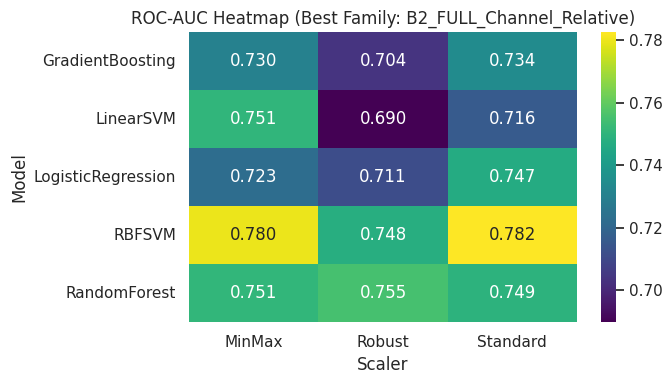

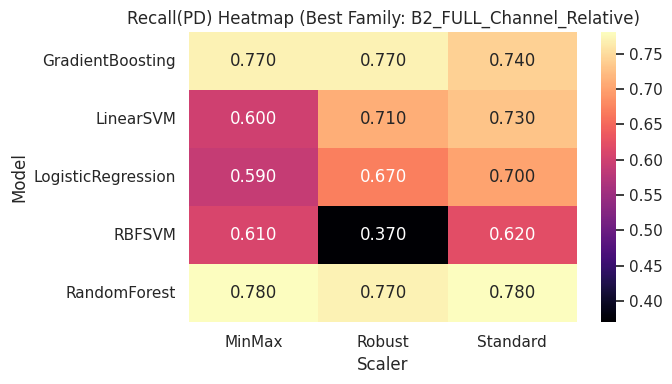

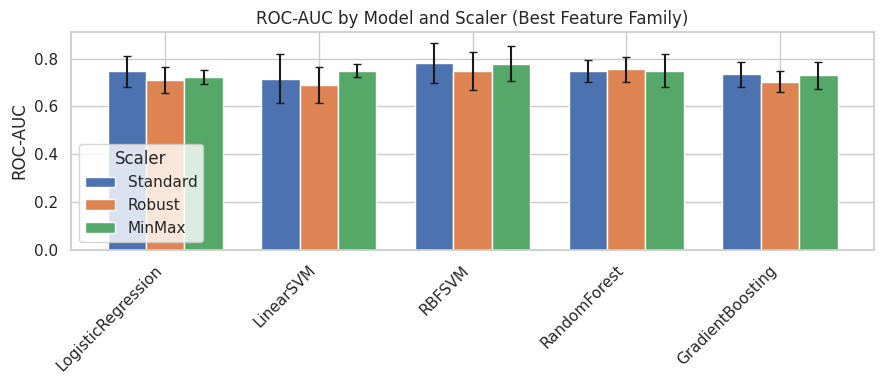

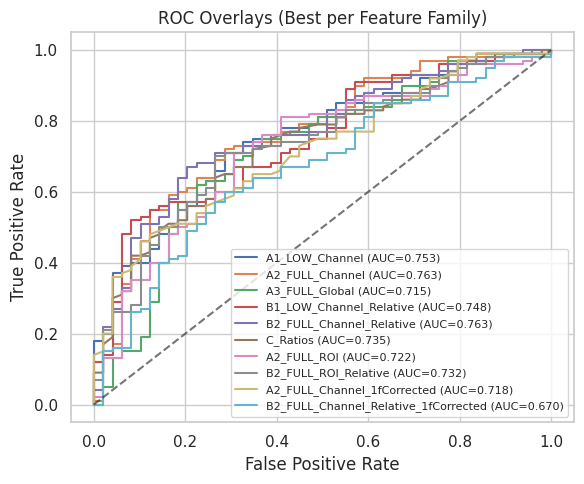

SHAP failed: The passed model is not callable and cannot be analyzed directly with the given masker! Model: Pipeline(steps=[('scaler', StandardScaler()), ('smote', SMOTE(random_state=42)),
                ('model', SVC(class_weight='balanced'))])


In [40]:
best_family = best_row["FeatureFamily"]
best_model = best_row["Model"]
best_scaler = best_row["Scaler"]

best_by_family = {}
for family_name in X_families:
    subset = results_df[results_df["FeatureFamily"] == family_name]
    ranked_subset = rank_configs(subset, top_n=1, verbose=False)
    best_by_family[family_name] = ranked_subset.iloc[0]

# Heatmap for the best feature family (ROC-AUC)
best_family_df = results_df[results_df["FeatureFamily"] == best_family]
heatmap_auc = best_family_df.pivot(index="Model", columns="Scaler", values="ROC_AUC_mean")

plt.figure(figsize=(7, 4))
sns.heatmap(heatmap_auc, annot=True, fmt=".3f", cmap="viridis")
plt.title(f"ROC-AUC Heatmap (Best Family: {best_family})")
plt.tight_layout()
plt.show()

# Optional recall heatmap for the same family
heatmap_recall = best_family_df.pivot(index="Model", columns="Scaler", values="Recall_mean")
plt.figure(figsize=(7, 4))
sns.heatmap(heatmap_recall, annot=True, fmt=".3f", cmap="magma")
plt.title(f"Recall(PD) Heatmap (Best Family: {best_family})")
plt.tight_layout()
plt.show()

# Grouped bar plot with error bars (std)
models_order = list(models.keys())
scalers_order = list(scalers.keys())

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(models_order))
width = 0.25
offsets = np.linspace(-width, width, len(scalers_order))

for i, scaler_name in enumerate(scalers_order):
    sub = (
        best_family_df[best_family_df["Scaler"] == scaler_name]
        .set_index("Model")
        .reindex(models_order)
    )
    ax.bar(
        x + offsets[i],
        sub["ROC_AUC_mean"],
        width,
        yerr=sub["ROC_AUC_std"],
        label=scaler_name,
        capsize=3,
    )

ax.set_xticks(x)
ax.set_xticklabels(models_order, rotation=45, ha="right")
ax.set_ylabel("ROC-AUC")
ax.set_title("ROC-AUC by Model and Scaler (Best Feature Family)")
ax.legend(title="Scaler")
plt.tight_layout()
plt.show()

# ROC curve overlays: best model per feature family

def get_cv_scores(pipeline, X, y, cv):
    if hasattr(pipeline, "decision_function"):
        scores = cross_val_predict(
            pipeline,
            X,
            y,
            cv=cv,
            method="decision_function",
            n_jobs=-1,
        )
    else:
        scores = cross_val_predict(
            pipeline,
            X,
            y,
            cv=cv,
            method="predict_proba",
            n_jobs=-1,
        )[:, 1]
    return scores

USE_SMOTE = USE_SMOTE if "USE_SMOTE" in globals() else False
SMOTE_K_NEIGHBORS = SMOTE_K_NEIGHBORS if "SMOTE_K_NEIGHBORS" in globals() else 5


def build_vis_pipeline(scaler, model):
    steps = [("scaler", clone(scaler))]
    if USE_SMOTE:
        steps.append(("smote", SMOTE(random_state=42, k_neighbors=SMOTE_K_NEIGHBORS)))
        steps.append(("model", clone(model)))
        return ImbPipeline(steps)
    steps.append(("model", clone(model)))
    return Pipeline(steps)


plt.figure(figsize=(6, 5))
for family_name, row in best_by_family.items():
    pipeline = build_vis_pipeline(scalers[row["Scaler"]], models[row["Model"]])
    X = X_families[family_name]
    scores = get_cv_scores(pipeline, X, y, cv)
    fpr, tpr, _ = roc_curve(y, scores)
    auc = roc_auc_score(y, scores)
    plt.plot(fpr, tpr, label=f"{family_name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.6)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Overlays (Best per Feature Family)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Feature importance (RF) or SHAP summary for best model
X_best = X_families[best_family]
best_pipeline = build_vis_pipeline(scalers[best_scaler], models[best_model])
best_pipeline.fit(X_best, y)

best_model_fitted = best_pipeline.named_steps["model"]

if hasattr(best_model_fitted, "feature_importances_"):
    imp_df = (
        pd.DataFrame({
            "feature": X_best.columns,
            "importance": best_model_fitted.feature_importances_,
        })
        .sort_values("importance", ascending=False)
        .head(20)
    )
    plt.figure(figsize=(7, 5))
    sns.barplot(data=imp_df, y="feature", x="importance", color="steelblue")
    plt.title("Top Feature Importances (Random Forest)")
    plt.tight_layout()
    plt.show()
else:
    try:
        sample = X_best.sample(n=min(50, len(X_best)), random_state=42)
        explainer = shap.Explainer(best_pipeline, sample)
        shap_values = explainer(sample)
        shap.plots.beeswarm(shap_values, max_display=20)
    except Exception as exc:
        print(f"SHAP failed: {exc}")


## SECTION 9 - Model Selection

We rank configurations using a medically motivated multi-criteria rule:
1) **Primary**: ROC-AUC mean (overall discrimination)
2) **Secondary**: ROC-AUC std (stability across folds; lower is better)
3) **Tertiary**: Recall(PD) mean (sensitivity for PD detection)

This prioritizes robust discrimination while explicitly rewarding sensitivity, which is appropriate for screening tasks where false negatives are costly.

In [41]:
best_row


,0
FeatureFamily,B2_FULL_Channel_Relative
Model,RBFSVM
Scaler,Standard
ROC_AUC_mean,0.782444
ROC_AUC_std,0.08483
BalAcc_mean,0.717778
BalAcc_std,0.098532
Recall_mean,0.62
Recall_std,0.09798


## SECTION 10 - Holdout Evaluation

### Why holdout can differ from CV
- **Small sample sizes** make single splits noisy; CV averages across folds and is more stable.
- **Fold composition variance** can favor or penalize specific feature families and models.
- **Thresholding and calibration** matter: for SVMs, raw decision scores are not probabilities.

### What we do here
- **Calibrate SVMs** on training data (sigmoid) to obtain meaningful probabilities.
- **Select a decision threshold** on training CV scores to emphasize PD recall.
- **Apply the chosen threshold** to the holdout set for fair evaluation.

Selected threshold (from training CV):
{'threshold': np.float64(0.49725450660313486), 'recall': np.float64(0.8), 'specificity': np.float64(0.41025641025641024), 'bal_acc': np.float64(0.6051282051282052)}
Holdout ROC-AUC: 0.815
Holdout Balanced Accuracy: 0.800
Holdout Recall (PD): 0.900

              precision    recall  f1-score   support

           0      0.778     0.700     0.737        10
           1      0.857     0.900     0.878        20

    accuracy                          0.833        30
   macro avg      0.817     0.800     0.807        30
weighted avg      0.831     0.833     0.831        30



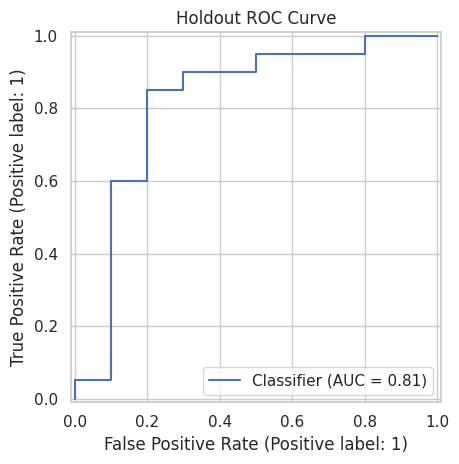

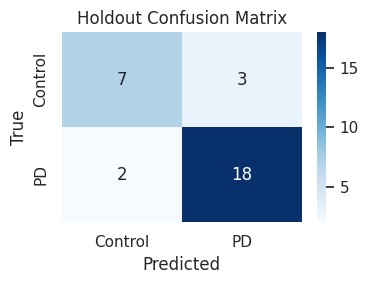

In [42]:
X_best = X_families[best_family]

X_train, X_test, y_train, y_test = train_test_split(
    X_best,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

CALIBRATE_SVM = True
CALIBRATION_METHOD = "sigmoid"
CALIBRATION_CV = 5
USE_SMOTE = USE_SMOTE if "USE_SMOTE" in globals() else False
SMOTE_K_NEIGHBORS = SMOTE_K_NEIGHBORS if "SMOTE_K_NEIGHBORS" in globals() else 5
TARGET_RECALL = 0.80


def make_estimator(scaler, model):
    steps = [("scaler", clone(scaler))]
    if USE_SMOTE:
        steps.append(("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=SMOTE_K_NEIGHBORS)))
        steps.append(("model", clone(model)))
        base = ImbPipeline(steps)
    else:
        steps.append(("model", clone(model)))
        base = Pipeline(steps)
    if CALIBRATE_SVM and isinstance(model, SVC):
        return CalibratedClassifierCV(
            estimator=base,
            method=CALIBRATION_METHOD,
            cv=CALIBRATION_CV,
        )
    return base


def get_scores(estimator, X, y=None, cv=None):
    if cv is not None:
        if hasattr(estimator, "predict_proba"):
            return cross_val_predict(
                estimator, X, y, cv=cv, method="predict_proba", n_jobs=-1
            )[:, 1]
        return cross_val_predict(
            estimator, X, y, cv=cv, method="decision_function", n_jobs=-1
        )
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]
    return estimator.decision_function(X)


best_estimator = make_estimator(scalers[best_scaler], models[best_model])

# Select threshold on training data using CV scores
train_scores_cv = get_scores(best_estimator, X_train, y_train, cv=cv)
threshold_info = select_threshold(y_train, train_scores_cv, target_recall=TARGET_RECALL)
threshold = threshold_info["threshold"]

print("Selected threshold (from training CV):")
print(threshold_info)

# Fit on full training set and evaluate on holdout
best_estimator.fit(X_train, y_train)

y_score = get_scores(best_estimator, X_test)
y_pred = (y_score >= threshold).astype(int)

roc_auc = roc_auc_score(y_test, y_score)
bal_acc = balanced_accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Holdout ROC-AUC: {roc_auc:.3f}")
print(f"Holdout Balanced Accuracy: {bal_acc:.3f}")
print(f"Holdout Recall (PD): {recall:.3f}\n")
print(classification_report(y_test, y_pred, digits=3))

RocCurveDisplay.from_predictions(y_test, y_score)
plt.title("Holdout ROC Curve")
plt.tight_layout()
plt.show()

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Control", "PD"],
    yticklabels=["Control", "PD"],
)
plt.title("Holdout Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


## SECTION 11 - Error Analysis

In [43]:
test_ids = X_test.index
fp_ids = test_ids[(y_test == 0) & (y_pred == 1)]
fn_ids = test_ids[(y_test == 1) & (y_pred == 0)]

print(f"False positives: {len(fp_ids)}")
print(f"False negatives: {len(fn_ids)}")
print("FP subject IDs (sample):", list(fp_ids[:10]))
print("FN subject IDs (sample):", list(fn_ids[:10]))

stability_by_model = results_df.groupby("Model")["ROC_AUC_std"].mean().sort_values()
stability_by_scaler = results_df.groupby("Scaler")["ROC_AUC_std"].mean().sort_values()

print("\nStability by model (lower std is better):")
print(stability_by_model)
print("\nStability by scaler (lower std is better):")
print(stability_by_scaler)

linear_models = ["LogisticRegression", "LinearSVM"]
nonlinear_models = ["RBFSVM", "RandomForest", "GradientBoosting"]

linear_auc = results_df[results_df["Model"].isin(linear_models)]["ROC_AUC_mean"].mean()
nonlinear_auc = results_df[results_df["Model"].isin(nonlinear_models)]["ROC_AUC_mean"].mean()

print(f"\nMean ROC-AUC (linear): {linear_auc:.3f}")
print(f"Mean ROC-AUC (nonlinear): {nonlinear_auc:.3f}")


False positives: 3
False negatives: 2
FP subject IDs (sample): ['sub-139', 'sub-115', 'sub-119']
FN subject IDs (sample): ['sub-071', 'sub-050']

Stability by model (lower std is better):
Model
RandomForest          0.055296
LogisticRegression    0.058894
GradientBoosting      0.060866
LinearSVM             0.068000
RBFSVM                0.084513
Name: ROC_AUC_std, dtype: float64

Stability by scaler (lower std is better):
Scaler
MinMax      0.060864
Robust      0.066346
Standard    0.069332
Name: ROC_AUC_std, dtype: float64

Mean ROC-AUC (linear): 0.685
Mean ROC-AUC (nonlinear): 0.717


## ADD-ON - Cognition Labeling (Executive Composite)

Tier codes follow the executive composite mapping used in the other files: 0 = preserved, 1 = standard, 2 = impaired.

In [44]:
# Load cognition labels from the clinical cognition file
COG_PATH = os.path.join(DATA_DIR, "participants_clin_cog.csv")

cog_df = pd.read_csv(COG_PATH)

cognitive_cols = ["NIH FICAT", "NIH DCCST", "NIH PCPST", "NIH PSMT", "NIH PVT"]
core_tests = ["NIH FICAT", "NIH DCCST", "NIH PCPST"]

# Match main.ipynb: require all cognitive tests and define Executive Composite
cog_df = cog_df.dropna(subset=cognitive_cols).copy()
controls = cog_df[cog_df["GROUP"] == "Control"]
control_means = controls[core_tests].mean()
control_stds = controls[core_tests].std()

z_scores = (cog_df[core_tests] - control_means) / control_stds
cog_df["Executive_Composite"] = z_scores.mean(axis=1)


def normative_map(z):
    if z < -1.0:
        return 2  # impaired
    if z < 0.0:
        return 1  # standard
    return 0  # preserved


cog_df["cog_tier"] = cog_df["Executive_Composite"].apply(normative_map)
cog_df["cog_tier_label"] = cog_df["cog_tier"].map(
    {0: "preserved", 1: "standard", 2: "impaired"}
)
cog_df["cog_binary"] = (cog_df["cog_tier"] == 2).astype(int)

# Align cognition labels to subjects with valid EEG features
cog_df = cog_df.set_index("participant_id")
cog_df = cog_df.loc[cog_df.index.intersection(valid_subjects)]

cog_mask = cog_df["cog_binary"].notna() & cog_df["cog_tier"].notna()
cog_df = cog_df.loc[cog_mask].copy()

cog_subjects = cog_df.index.tolist()
y_cog_binary = cog_df["cog_binary"].astype(int).values
y_cog_tiered = cog_df["cog_tier"].astype(int).values

X_cog_families = {name: X.loc[cog_subjects] for name, X in X_families.items()}

print("Cognition subjects:", len(cog_subjects))
print("Tier counts (0 = Preserved, 1 = Standard, 2 = Impaired):")
print(cog_df["cog_tier"].value_counts().sort_index())
print(
    "Binary cognition counts (0 = Not impaired, 1 = Impaired):",
    {
        "not_impaired": int((y_cog_binary == 0).sum()),
        "impaired": int((y_cog_binary == 1).sum()),
    },
)


Cognition subjects: 138
Tier counts (0 = Preserved, 1 = Standard, 2 = Impaired):
cog_tier
0    32
1    59
2    47
Name: count, dtype: int64
Binary cognition counts (0 = Not impaired, 1 = Impaired): {'not_impaired': 91, 'impaired': 47}


In [45]:

cog_scoring = {
    "roc_auc": "roc_auc",
    "balanced_acc": "balanced_accuracy",
    "accuracy": "accuracy",
    "f1": "f1",
}

cog_results = []

for family_name, X in X_cog_families.items():
    pipeline = build_cv_pipeline(StandardScaler(), models["RandomForest"])
    scores = cross_validate(
        pipeline,
        X,
        y_cog_binary,
        cv=cv,
        scoring=cog_scoring,
        n_jobs=-1,
        return_train_score=False,
    )
    cog_results.append(
        {
            "FeatureFamily": family_name,
            "Model": "RandomForest",
            "ROC_AUC_mean": np.mean(scores["test_roc_auc"]),
            "ROC_AUC_std": np.std(scores["test_roc_auc"]),
            "BalAcc_mean": np.mean(scores["test_balanced_acc"]),
            "BalAcc_std": np.std(scores["test_balanced_acc"]),
            "Accuracy_mean": np.mean(scores["test_accuracy"]),
            "Accuracy_std": np.std(scores["test_accuracy"]),
            "F1_mean": np.mean(scores["test_f1"]),
            "F1_std": np.std(scores["test_f1"]),
        }
    )

cog_results_df = pd.DataFrame(cog_results).sort_values(
    "ROC_AUC_mean", ascending=False
)

print("Binary cognition CV (RandomForest) — mean ± std")
print(cog_results_df.head(10))

# Confusion matrix + tiered generalization on the best feature family
best_family = cog_results_df.iloc[0]["FeatureFamily"]
best_X = X_cog_families[best_family]

pipeline = build_cv_pipeline(StandardScaler(), models["RandomForest"])

# Out-of-fold probabilities from the binary cognition model
binary_probs = cross_val_predict(
    pipeline,
    best_X,
    y_cog_binary,
    cv=cv,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

binary_pred = (binary_probs >= 0.5).astype(int)
cm = confusion_matrix(y_cog_binary, binary_pred, labels=[0, 1])

print(f"\nBest family: {best_family}")
print("Confusion matrix (0=not impaired, 1=impaired):")
print(cm)

binary_prob_series = pd.Series(binary_probs, index=cog_df.index)

print("\nTiered cognition trend (mean P(impaired) by tier):")
for tier_label in ["preserved", "standard", "impaired"]:
    tier_mean = binary_prob_series[cog_df["cog_tier_label"] == tier_label].mean()
    print(f"{tier_label}: {tier_mean:.3f}")

rho, pval = spearmanr(binary_prob_series.values, y_cog_tiered)
print(f"\nSpearman rho (binary prob vs tiered code): {rho:.3f}, p={pval:.4g}")

print("\nPairwise AUCs (tiered cognition):")
pairs = [("impaired", "standard"), ("standard", "preserved"), ("impaired", "preserved")]
for pos, neg in pairs:
    mask = cog_df["cog_tier_label"].isin([pos, neg])
    y_pair = (cog_df.loc[mask, "cog_tier_label"] == pos).astype(int)
    auc = roc_auc_score(y_pair, binary_prob_series.loc[mask])
    print(f"{pos} vs {neg}: AUC={auc:.3f}")


Binary cognition CV (RandomForest) — mean ± std
                          FeatureFamily         Model  ROC_AUC_mean  \
1                       A2_FULL_Channel  RandomForest      0.781001   
6                           A2_FULL_ROI  RandomForest      0.780019   
8           A2_FULL_Channel_1fCorrected  RandomForest      0.779113   
5                              C_Ratios  RandomForest      0.766475   
2                        A3_FULL_Global  RandomForest      0.765273   
4              B2_FULL_Channel_Relative  RandomForest      0.764893   
0                        A1_LOW_Channel  RandomForest      0.759883   
7                  B2_FULL_ROI_Relative  RandomForest      0.758096   
3               B1_LOW_Channel_Relative  RandomForest      0.757888   
9  B2_FULL_Channel_Relative_1fCorrected  RandomForest      0.753483   

   ROC_AUC_std  BalAcc_mean  BalAcc_std  Accuracy_mean  Accuracy_std  \
1     0.109243     0.737602    0.103249       0.775661      0.099256   
6     0.086355     0.70286

### Cognition Visualizations

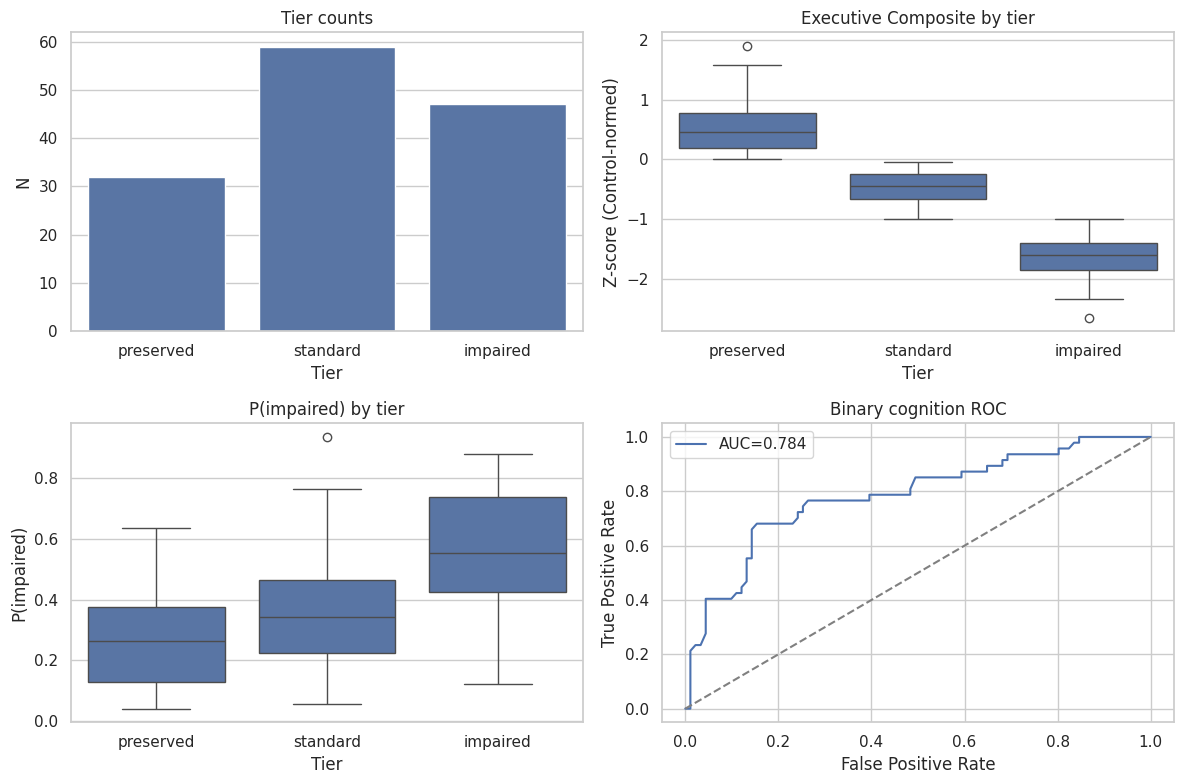

In [46]:
# Requires outputs from the cognition evaluation cell
if "binary_prob_series" not in globals():
    raise RuntimeError("Run the cognition evaluation cell before visualizations.")

tier_order = ["preserved", "standard", "impaired"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Tier counts
counts = cog_df["cog_tier_label"].value_counts().reindex(tier_order)
sns.barplot(x=counts.index, y=counts.values, ax=axes[0, 0])
axes[0, 0].set_title("Tier counts")
axes[0, 0].set_xlabel("Tier")
axes[0, 0].set_ylabel("N")

# Executive Composite by tier
sns.boxplot(
    data=cog_df,
    x="cog_tier_label",
    y="Executive_Composite",
    order=tier_order,
    ax=axes[0, 1],
)
axes[0, 1].set_title("Executive Composite by tier")
axes[0, 1].set_xlabel("Tier")
axes[0, 1].set_ylabel("Z-score (Control-normed)")

# Predicted impairment probability by tier
prob_df = pd.DataFrame(
    {"prob_impaired": binary_prob_series.values, "tier": cog_df["cog_tier_label"].values}
)
sns.boxplot(data=prob_df, x="tier", y="prob_impaired", order=tier_order, ax=axes[1, 0])
axes[1, 0].set_title("P(impaired) by tier")
axes[1, 0].set_xlabel("Tier")
axes[1, 0].set_ylabel("P(impaired)")

# ROC curve (binary cognition)
fpr, tpr, _ = roc_curve(y_cog_binary, binary_prob_series.values)
auc = roc_auc_score(y_cog_binary, binary_prob_series.values)
axes[1, 1].plot(fpr, tpr, label=f"AUC={auc:.3f}")
axes[1, 1].plot([0, 1], [0, 1], "--", color="gray")
axes[1, 1].set_title("Binary cognition ROC")
axes[1, 1].set_xlabel("False Positive Rate")
axes[1, 1].set_ylabel("True Positive Rate")
axes[1, 1].legend()

plt.tight_layout()
plt.show()


## SECTION 12 - Discussion

- **Relation to unsupervised low-frequency findings:** The low-frequency bandpower families directly mirror the unsupervised pipeline, allowing us to test whether the same slowing patterns carry discriminative signal for PD.
- **Does beta improve discrimination?** Comparing low-band (delta/theta) versus full-spectrum (including beta) reveals whether higher-frequency dynamics add separability beyond slowing alone.
- **Spatial vs global representation:** Channel-wise features capture spatial heterogeneity, while global features test whether coarse summaries suffice for classification.
- **Stability of normalization:** Scaler-dependent variance in ROC-AUC reflects how sensitive each feature family is to scaling choices, especially for ratio-based features.
- **Dataset size limitations:** With a modest number of subjects, model complexity is constrained; cross-validation variance and holdout uncertainty should be interpreted conservatively.
- **Risk of overfitting:** Feature dimensionality can outpace sample size; consistent performance across folds and scalers is essential evidence against overfitting.


### Advanced Cognition Visualizations

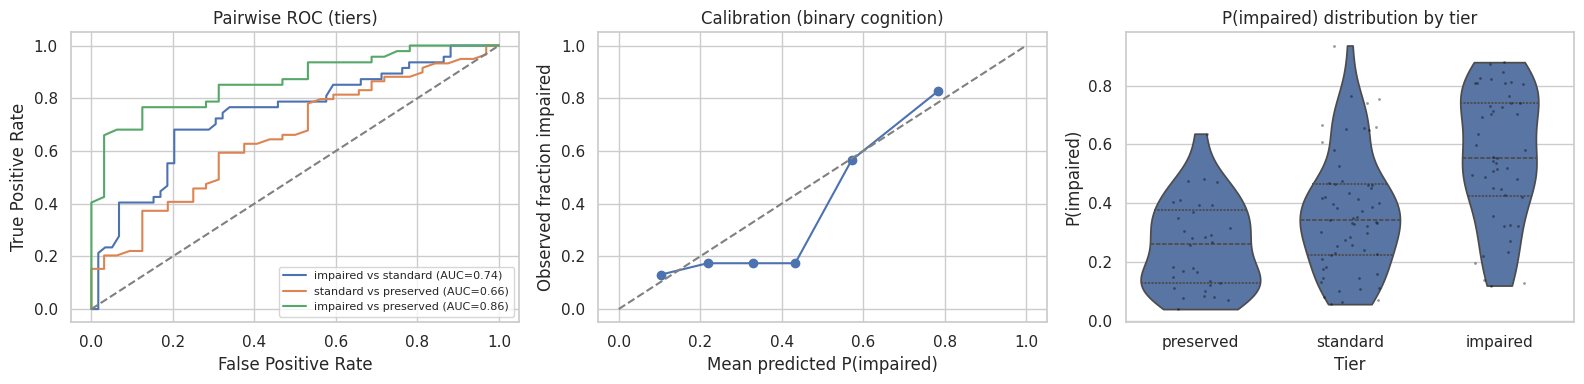

In [47]:
# Requires outputs from the cognition evaluation cell
if "binary_prob_series" not in globals():
    raise RuntimeError("Run the cognition evaluation cell before visualizations.")

tier_order = ["preserved", "standard", "impaired"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Pairwise ROC across tiers
pairs = [("impaired", "standard"), ("standard", "preserved"), ("impaired", "preserved")]
for pos, neg in pairs:
    mask = cog_df["cog_tier_label"].isin([pos, neg])
    y_pair = (cog_df.loc[mask, "cog_tier_label"] == pos).astype(int)
    fpr, tpr, _ = roc_curve(y_pair, binary_prob_series.loc[mask])
    auc = roc_auc_score(y_pair, binary_prob_series.loc[mask])
    axes[0].plot(fpr, tpr, label=f"{pos} vs {neg} (AUC={auc:.2f})")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_title("Pairwise ROC (tiers)")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(fontsize=8)

# Calibration curve (binary cognition)
frac_pos, mean_pred = calibration_curve(
    y_cog_binary, binary_prob_series.values, n_bins=6, strategy="quantile"
)
axes[1].plot(mean_pred, frac_pos, marker="o")
axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].set_title("Calibration (binary cognition)")
axes[1].set_xlabel("Mean predicted P(impaired)")
axes[1].set_ylabel("Observed fraction impaired")

# Distribution of P(impaired) by tier
prob_df = pd.DataFrame(
    {"prob_impaired": binary_prob_series.values, "tier": cog_df["cog_tier_label"].values}
)
sns.violinplot(
    data=prob_df,
    x="tier",
    y="prob_impaired",
    order=tier_order,
    ax=axes[2],
    inner="quartile",
    cut=0,
)
sns.stripplot(
    data=prob_df,
    x="tier",
    y="prob_impaired",
    order=tier_order,
    ax=axes[2],
    color="black",
    size=2,
    alpha=0.4,
    jitter=0.2,
)
axes[2].set_title("P(impaired) distribution by tier")
axes[2].set_xlabel("Tier")
axes[2].set_ylabel("P(impaired)")

plt.tight_layout()
plt.show()


## ADD-ON - PD ↔ Cognition (EEG-based cross-label)

Goal: use the EEG-based PD model to see whether PD probability tracks cognitive tier severity. This reuses the PD EEG features and evaluates how P(PD) changes across preserved → standard → impaired cognition.

PD model family: B2_FULL_Channel_Relative | model: RBFSVM

PD score by cognition tier:
preserved: -0.337
standard: -0.131
impaired: 0.463

Spearman rho (PD score vs tier code): 0.411, p=5.416e-07

PD AUC within each cognition tier:
preserved: AUC=0.608
standard: AUC=0.738
impaired: AUC=0.811


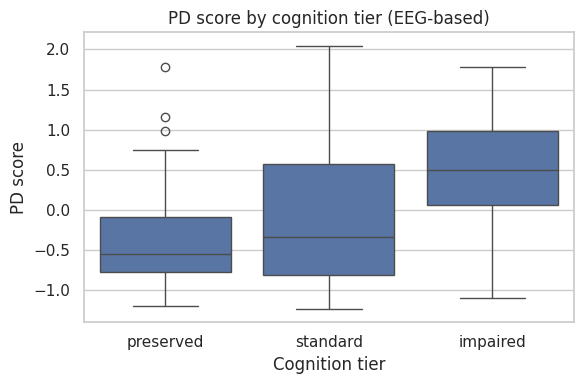

In [48]:
# Requires cognition labels and EEG features
required = ["cog_df", "X_families", "participants", "build_cv_pipeline", "models", "cv"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Missing prerequisites: {missing}")

# Pick PD feature family (prefer best_row if available)
if "best_row" in globals() and "FeatureFamily" in best_row:
    pd_family = best_row["FeatureFamily"]
    pd_model_name = best_row.get("Model", "RandomForest")
elif "best_family" in globals():
    pd_family = best_family
    pd_model_name = "RandomForest"
else:
    pd_family = list(X_families.keys())[0]
    pd_model_name = "RandomForest"

pd_model = models.get(pd_model_name, models["RandomForest"])

# Align PD labels to cognition subjects
participants_idx = participants.set_index("participant_id")
if "PD_label" in participants_idx.columns:
    y_pd_series = participants_idx.loc[cog_df.index, "PD_label"].astype(int)
else:
    y_pd_series = (participants_idx.loc[cog_df.index, "GROUP"] == "PD").astype(int)

y_pd = y_pd_series.values
X_pd = X_families[pd_family].loc[cog_df.index]

# PD scores from EEG features (out-of-fold)
pd_pipeline = build_cv_pipeline(StandardScaler(), pd_model)

use_proba = hasattr(pd_model, "predict_proba")
if use_proba:
    pd_scores = cross_val_predict(
        pd_pipeline,
        X_pd,
        y_pd,
        cv=cv,
        method="predict_proba",
        n_jobs=-1,
    )[:, 1]
    score_label = "P(PD)"
else:
    pd_scores = cross_val_predict(
        pd_pipeline,
        X_pd,
        y_pd,
        cv=cv,
        method="decision_function",
        n_jobs=-1,
    )
    score_label = "PD score"

pd_score_series = pd.Series(pd_scores, index=cog_df.index)

print(f"PD model family: {pd_family} | model: {pd_model_name}")
print(f"\n{score_label} by cognition tier:")
for tier_label in ["preserved", "standard", "impaired"]:
    tier_mean = pd_score_series[cog_df["cog_tier_label"] == tier_label].mean()
    print(f"{tier_label}: {tier_mean:.3f}")

rho, pval = spearmanr(pd_score_series.values, cog_df["cog_tier"].values)
print(f"\nSpearman rho ({score_label} vs tier code): {rho:.3f}, p={pval:.4g}")

print("\nPD AUC within each cognition tier:")
for tier_label in ["preserved", "standard", "impaired"]:
    mask = cog_df["cog_tier_label"] == tier_label
    y_sub = y_pd_series.loc[mask]
    if y_sub.nunique() < 2:
        print(f"{tier_label}: skipped (single class)")
        continue
    auc = roc_auc_score(y_sub, pd_score_series.loc[mask])
    print(f"{tier_label}: AUC={auc:.3f}")

# Visualization: PD score by cognition tier
plt.figure(figsize=(6, 4))
sns.boxplot(
    x=cog_df["cog_tier_label"],
    y=pd_score_series.values,
    order=["preserved", "standard", "impaired"],
)
plt.title(f"{score_label} by cognition tier (EEG-based)")
plt.xlabel("Cognition tier")
plt.ylabel(score_label)
plt.tight_layout()
plt.show()


## ADD-ON - Cognition Label Shuffle (Sanity Check)

Purpose: confirm cognition classification is above chance by comparing real AUC to a distribution from shuffled labels (same CV/pipeline).

Cognition shuffle sanity check (family=A2_FULL_Channel)
Real AUC: 0.781
Shuffled AUC mean ± std: 0.491 ± 0.065
Permutation p-value: 0.0050


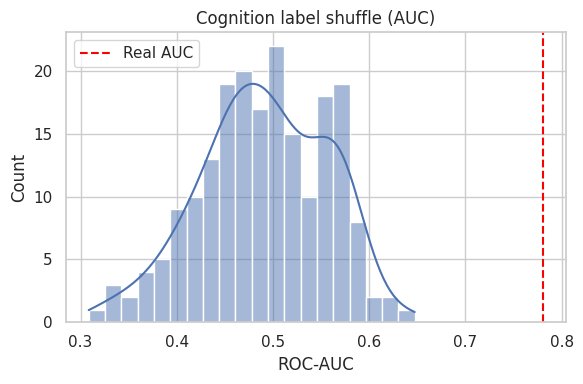

In [49]:

required = ["X_cog_families", "y_cog_binary", "cv", "build_cv_pipeline", "models"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Missing prerequisites: {missing}")

N_SHUFFLES = 200
rng = np.random.RandomState(RANDOM_STATE)

if "cog_results_df" in globals() and len(cog_results_df):
    shuffle_family = cog_results_df.iloc[0]["FeatureFamily"]
else:
    shuffle_family = list(X_cog_families.keys())[0]

X_shuffle = X_cog_families[shuffle_family]
shuffle_pipeline = build_cv_pipeline(StandardScaler(), models["RandomForest"])

real_auc = cross_val_score(
    shuffle_pipeline,
    X_shuffle,
    y_cog_binary,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
).mean()

shuffled_aucs = []
for _ in range(N_SHUFFLES):
    y_shuff = rng.permutation(y_cog_binary)
    auc = cross_val_score(
        shuffle_pipeline,
        X_shuffle,
        y_shuff,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1,
    ).mean()
    shuffled_aucs.append(auc)

shuffled_aucs = np.array(shuffled_aucs)

p_val = (np.sum(shuffled_aucs >= real_auc) + 1) / (N_SHUFFLES + 1)

print(f"Cognition shuffle sanity check (family={shuffle_family})")
print(f"Real AUC: {real_auc:.3f}")
print(f"Shuffled AUC mean ± std: {shuffled_aucs.mean():.3f} ± {shuffled_aucs.std():.3f}")
print(f"Permutation p-value: {p_val:.4f}")

plt.figure(figsize=(6, 4))
sns.histplot(shuffled_aucs, bins=20, kde=True)
plt.axvline(real_auc, color="red", linestyle="--", label="Real AUC")
plt.title("Cognition label shuffle (AUC)")
plt.xlabel("ROC-AUC")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


## ADD-ON - PD Label Shuffle (Sanity Check)

Purpose: confirm PD classification is above chance by comparing real AUC to a shuffled-label distribution (same CV/pipeline).

PD shuffle sanity check (family=B2_FULL_Channel_Relative, model=RBFSVM)
Real AUC: 0.782
Shuffled AUC mean ± std: 0.503 ± 0.068
Permutation p-value: 0.0050


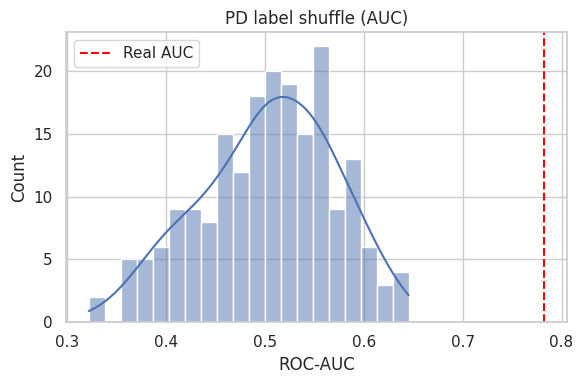

In [50]:
required = ["X_families", "cv", "build_cv_pipeline", "models"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Missing prerequisites: {missing}")

N_SHUFFLES = 200
rng = np.random.RandomState(RANDOM_STATE)

# Choose PD feature family/model
if "best_row" in globals() and "FeatureFamily" in best_row:
    pd_family = best_row["FeatureFamily"]
    pd_model_name = best_row.get("Model", "RandomForest")
elif "best_family" in globals():
    pd_family = best_family
    pd_model_name = "RandomForest"
else:
    pd_family = list(X_families.keys())[0]
    pd_model_name = "RandomForest"

pd_model = models.get(pd_model_name, models["RandomForest"])

X_pd = X_families[pd_family]

# PD labels aligned to X_pd
if "y" in globals() and len(y) == len(X_pd):
    y_pd = np.array(y)
else:
    participants_idx = participants.set_index("participant_id")
    y_pd = participants_idx.loc[X_pd.index, "PD_label"].astype(int).values

pd_pipeline = build_cv_pipeline(StandardScaler(), pd_model)

real_auc = cross_val_score(
    pd_pipeline,
    X_pd,
    y_pd,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
).mean()

shuffled_aucs = []
for _ in range(N_SHUFFLES):
    y_shuff = rng.permutation(y_pd)
    auc = cross_val_score(
        pd_pipeline,
        X_pd,
        y_shuff,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1,
    ).mean()
    shuffled_aucs.append(auc)

shuffled_aucs = np.array(shuffled_aucs)

p_val = (np.sum(shuffled_aucs >= real_auc) + 1) / (N_SHUFFLES + 1)

print(f"PD shuffle sanity check (family={pd_family}, model={pd_model_name})")
print(f"Real AUC: {real_auc:.3f}")
print(f"Shuffled AUC mean ± std: {shuffled_aucs.mean():.3f} ± {shuffled_aucs.std():.3f}")
print(f"Permutation p-value: {p_val:.4f}")

plt.figure(figsize=(6, 4))
sns.histplot(shuffled_aucs, bins=20, kde=True)
plt.axvline(real_auc, color="red", linestyle="--", label="Real AUC")
plt.title("PD label shuffle (AUC)")
plt.xlabel("ROC-AUC")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()
